# AI Client Project 4 — Quora Question Pairs

## Business Case
Determine whether two user questions express essentially the same meaning using human-labeled question pairs.

## Project Goal
Build a binary classification model that predicts whether a pair of questions is duplicate.

## Dataset
- `question1`, `question2`: paired question text
- `is_duplicate`: target (1 = duplicate, 0 = not duplicate)

## Approach
Data understanding → EDA → leakage-safe text preprocessing → stratified split → baseline → systematic `GridSearchCV` → final model → untouched test evaluation → error analysis → limitations and future scope.

### Modelling note
The dataset contains more than 400,000 labeled pairs. A hashing-based sparse text representation is used to keep memory and runtime practical while retaining word unigram/bigram information. The classifier is a linear SGD model with logistic loss. Hyperparameter tuning is performed with `GridSearchCV`. Standard tabular scaling and SMOTE are not applied because sparse text features do not require those transformations and synthetic interpolation of sparse text vectors is not an appropriate default.

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import HashingVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay
warnings.filterwarnings("ignore")
DATA_PATH = r"/mnt/data/quora_work/train.csv"
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()

Shape: (404290, 6)


,id,qid1,qid2,question1,question2,is_duplicate
0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0
1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0
2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0
3,3,7,8,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0
4,4,9,10,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0


In [2]:
print(df.info())
print("Missing values:")
print(df.isna().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nTarget counts:")
print(df["is_duplicate"].value_counts())
print("\nTarget proportions:")
print(df["is_duplicate"].value_counts(normalize=True).round(4))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404290 entries, 0 to 404289
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            404290 non-null  int64 
 1   qid1          404290 non-null  int64 
 2   qid2          404290 non-null  int64 
 3   question1     404289 non-null  object
 4   question2     404288 non-null  object
 5   is_duplicate  404290 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 18.5+ MB
None
Missing values:
id              0
qid1            0
qid2            0
question1       1
question2       2
is_duplicate    0
dtype: int64

Duplicate rows: 0

Target counts:
is_duplicate
0    255027
1    149263
Name: count, dtype: int64

Target proportions:
is_duplicate
0    0.6308
1    0.3692
Name: proportion, dtype: float64


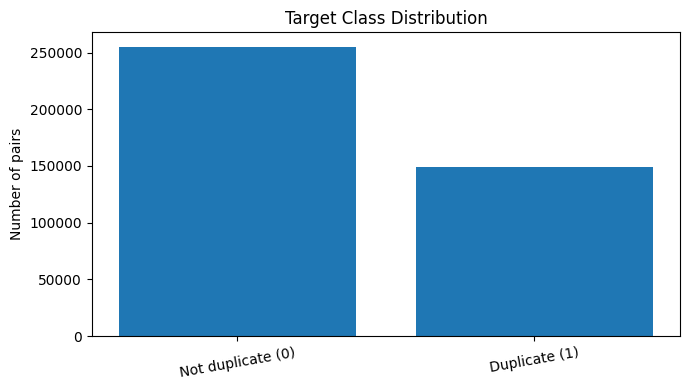

In [3]:
counts=df["is_duplicate"].value_counts().sort_index()
plt.figure(figsize=(7,4)); plt.bar(["Not duplicate (0)","Duplicate (1)"],counts.values)
plt.title("Target Class Distribution"); plt.ylabel("Number of pairs"); plt.xticks(rotation=10); plt.tight_layout(); plt.show()

In [4]:
df["question1"]=df["question1"].fillna("").astype(str)
df["question2"]=df["question2"].fillna("").astype(str)
df["q1_len"]=df["question1"].str.len(); df["q2_len"]=df["question2"].str.len()
df["q1_words"]=df["question1"].str.split().str.len(); df["q2_words"]=df["question2"].str.split().str.len()
print(df[["q1_len","q2_len","q1_words","q2_words"]].describe().round(2))

          q1_len     q2_len   q1_words   q2_words
count  404290.00  404290.00  404290.00  404290.00
mean       59.54      60.11      10.94      11.18
std        29.94      33.86       5.43       6.31
min         0.00       0.00       0.00       0.00
25%        39.00      39.00       7.00       7.00
50%        52.00      51.00      10.00      10.00
75%        72.00      72.00      13.00      13.00
max       623.00    1169.00     125.00     237.00


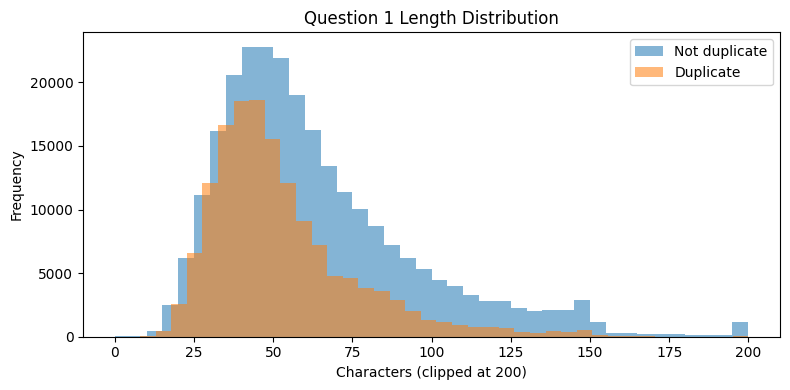

In [5]:
plt.figure(figsize=(8,4))
plt.hist(df.loc[df.is_duplicate==0,"q1_len"].clip(upper=200),bins=40,alpha=.55,label="Not duplicate")
plt.hist(df.loc[df.is_duplicate==1,"q1_len"].clip(upper=200),bins=40,alpha=.55,label="Duplicate")
plt.title("Question 1 Length Distribution"); plt.xlabel("Characters (clipped at 200)"); plt.ylabel("Frequency"); plt.legend(); plt.tight_layout(); plt.show()

## Data split
The data is split into training, validation, and test sets using stratification. The final test set is held back until the end.

In [6]:
df["text_pair"]=df["question1"]+" [SEP] "+df["question2"]
X=df["text_pair"]; y=df["is_duplicate"]
X_train,X_temp,y_train,y_temp=train_test_split(X,y,test_size=.30,random_state=42,stratify=y)
X_val,X_test,y_val,y_test=train_test_split(X_temp,y_temp,test_size=.50,random_state=42,stratify=y_temp)
print("Train:",len(X_train),"Validation:",len(X_val),"Test:",len(X_test))
print("Duplicate rates:",round(y_train.mean(),4),round(y_val.mean(),4),round(y_test.mean(),4))

Train: 283003 Validation: 60643 Test: 60644
Duplicate rates: 0.3692 0.3692 0.3692


## Baseline
A linear classifier with a fixed hashing text representation provides a fast baseline suitable for high-dimensional sparse text.

In [7]:
baseline=Pipeline([("text",HashingVectorizer(n_features=2**15,alternate_sign=False,ngram_range=(1,2),stop_words="english",norm="l2")),("clf",SGDClassifier(loss="log_loss",alpha=1e-5,max_iter=20,early_stopping=True,random_state=42,n_jobs=-1))])
baseline.fit(X_train,y_train); bp=baseline.predict(X_val)
p,r,f,_=precision_recall_fscore_support(y_val,bp,average="binary",zero_division=0)
print({"accuracy":round(accuracy_score(y_val,bp),4),"precision":round(p,4),"recall":round(r,4),"f1":round(f,4)})

{'accuracy': 0.7558, 'precision': 0.7641, 'recall': 0.4899, 'f1': 0.597}


## Systematic hyperparameter tuning
`GridSearchCV` compares several regularization strengths using 2-fold cross-validation on a representative 15,000-pair subset of the training data. The chosen configuration is then refit on the complete training split.

In [8]:
rng=np.random.RandomState(42); n=min(15000,len(X_train)); idx=rng.choice(len(X_train),n,replace=False)
X_tune=X_train.iloc[idx]; y_tune=y_train.iloc[idx]
search_pipe=Pipeline([("text",HashingVectorizer(n_features=2**15,alternate_sign=False,ngram_range=(1,2),stop_words="english",norm="l2")),("clf",SGDClassifier(loss="log_loss",max_iter=20,early_stopping=True,random_state=42,n_jobs=-1))])
param_grid={"clf__alpha":[1e-6,1e-5,1e-4],"clf__class_weight":["balanced"]}
grid=GridSearchCV(search_pipe,param_grid,scoring="f1",cv=2,n_jobs=-1)
grid.fit(X_tune,y_tune)
print("Best parameters:",grid.best_params_)
print("Best CV F1:",round(grid.best_score_,4))

Best parameters: {'clf__alpha': 0.0001, 'clf__class_weight': 'balanced'}
Best CV F1: 0.5587


In [9]:
pd.DataFrame(grid.cv_results_)[["param_clf__alpha","mean_test_score","std_test_score","rank_test_score"]].sort_values("rank_test_score").rename(columns={"mean_test_score":"mean_cv_f1","std_test_score":"std_cv_f1"})

,param_clf__alpha,mean_cv_f1,std_cv_f1,rank_test_score
2,0.000100,0.558657,0.013028,1
1,0.000010,0.552848,0.006855,2
0,0.000001,0.550082,0.010736,3


## Final model
The best hyperparameter is refit on the complete training split. The validation split is used for model checking; the test split remains untouched until final evaluation.

In [10]:
best_alpha=grid.best_params_["clf__alpha"]
final_model=Pipeline([("text",HashingVectorizer(n_features=2**15,alternate_sign=False,ngram_range=(1,2),stop_words="english",norm="l2")),("clf",SGDClassifier(loss="log_loss",alpha=best_alpha,class_weight="balanced",max_iter=30,early_stopping=True,random_state=42,n_jobs=-1))])
final_model.fit(X_train,y_train)
vp=final_model.predict(X_val)
print(classification_report(y_val,vp,digits=4))

              precision    recall  f1-score   support

           0     0.7730    0.7748    0.7739     38254
           1     0.6137    0.6113    0.6125     22389

    accuracy                         0.7145     60643
   macro avg     0.6934    0.6931    0.6932     60643
weighted avg     0.7142    0.7145    0.7143     60643



In [11]:
tp=final_model.predict(X_test); scores=final_model.decision_function(X_test)
p,r,f,_=precision_recall_fscore_support(y_test,tp,average="binary",zero_division=0)
metrics=pd.DataFrame({"Metric":["Accuracy","Precision","Recall","F1-score","ROC-AUC"],"Test value":[accuracy_score(y_test,tp),p,r,f,roc_auc_score(y_test,scores)]})
metrics["Test value"]=metrics["Test value"].round(4); metrics

,Metric,Test value
0,Accuracy,0.7153
1,Precision,0.6147
2,Recall,0.6131
3,F1-score,0.6139
4,ROC-AUC,0.7679


[[29649  8605]
 [ 8663 13727]]


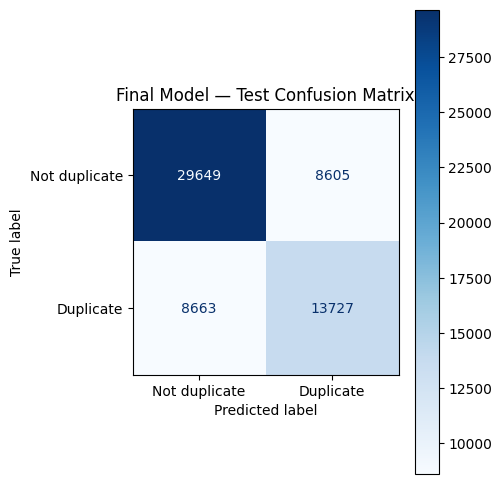

In [12]:
cm=confusion_matrix(y_test,tp)
print(cm)
fig,ax=plt.subplots(figsize=(5,5)); ConfusionMatrixDisplay(cm,display_labels=["Not duplicate","Duplicate"]).plot(ax=ax,values_format="d",cmap="Blues"); plt.title("Final Model — Test Confusion Matrix"); plt.tight_layout(); plt.show()

## Error analysis

In [13]:
ev=pd.DataFrame({"pair":X_test.reset_index(drop=True).str.replace(" [SEP] "," | ",regex=False),"actual":y_test.reset_index(drop=True),"predicted":tp})
errors=ev[ev.actual!=ev.predicted]
print("Test errors:",len(errors)); errors.head(10)

Test errors: 17268


,pair,actual,predicted
0,Are snails born with their shells? | Are snail...,1,0
2,Why is it important to have hobbies? | Why sho...,1,0
9,How can I make this pattern in c programming 1...,0,1
11,Which are the best/good universities in USA fo...,1,0
20,Is it wrong for an 18-year-old to be in a rela...,1,0
25,What are the best social media platforms to us...,1,0
27,What causes an upset stomach? | How do you tre...,1,0
29,"Who has more magical potential, Dumbledore or ...",1,0
31,How can I wake myself up when I'm tired? | How...,1,0
32,What are the best websites in Germany for clas...,0,1


## Example predictions

In [14]:
examples=pd.DataFrame({"question1":X_test.reset_index(drop=True).str.split(" [SEP] ").str[0].head(5),"question2":X_test.reset_index(drop=True).str.split(" [SEP] ").str[1].head(5),"actual":y_test.reset_index(drop=True).head(5).values,"predicted":tp[:5]}); examples

,question1,question2,actual,predicted
0,Are snails born with their shells? [SEP] Are s...,NaN,1,0
1,How do I get more topic diversity in my Quora ...,NaN,1,1
2,Why is it important to have hobbies? [SEP] Why...,NaN,1,0
3,What are the largest cities in CK2? [SEP] What...,NaN,0,0
4,Will YouTube pay $1 for 1000 views? Why am I n...,NaN,0,0


## Limitations and Challenges
- Human duplicate labels can be subjective or noisy.
- Lexical features do not fully capture deep semantic meaning or context.
- The dataset is imbalanced, so accuracy alone is insufficient.
- Hyperparameter search uses a representative subset to reduce computation; the selected model is then refit on the full training split.
- A production system may require stronger semantic models and threshold calibration.

## Future Scope
- Use sentence-transformer or transformer embeddings for deeper semantic similarity.
- Add question-level graph and duplicate-cluster features.
- Tune decision thresholds according to business precision/recall requirements.
- Monitor topic and language drift.
- Evaluate difficult paraphrase and adversarial examples separately.

## Conclusion
The completed pipeline performs leakage-safe text preprocessing, establishes a baseline, applies systematic `GridSearchCV` tuning, refits the selected model, evaluates it on an untouched test set, and documents errors, limitations, and future improvements. It provides a practical baseline for duplicate-question detection while identifying a clear path toward stronger semantic models.